In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [4]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [5]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [6]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [7]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

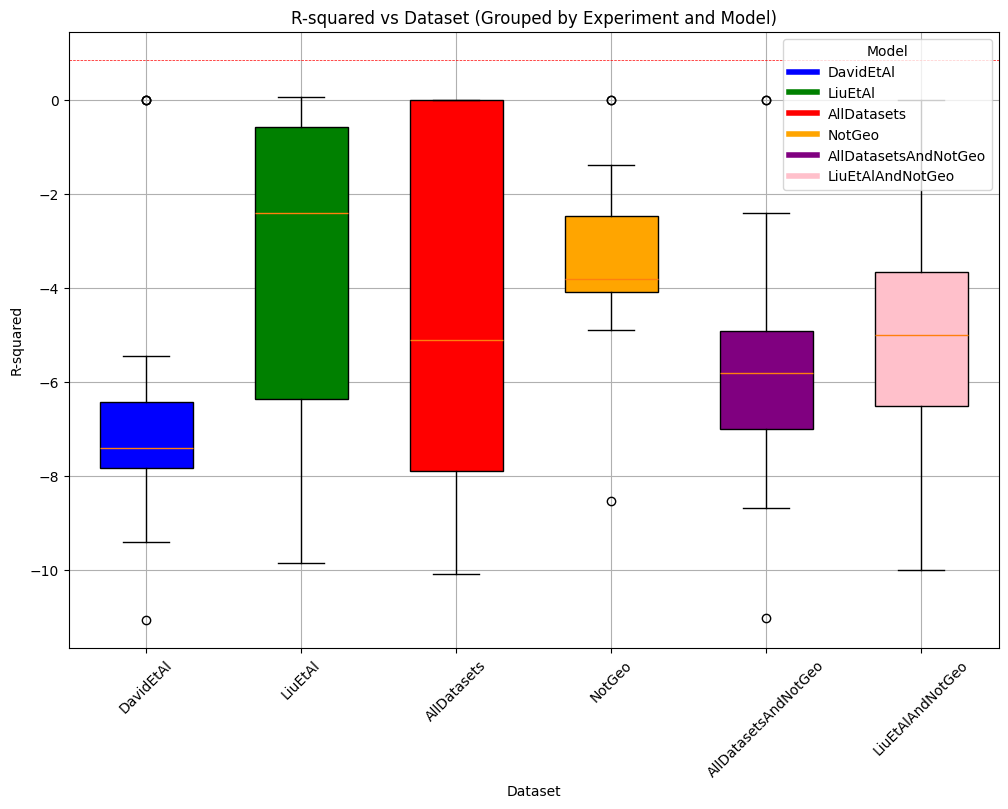

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
# filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset
# filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['r_squared'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

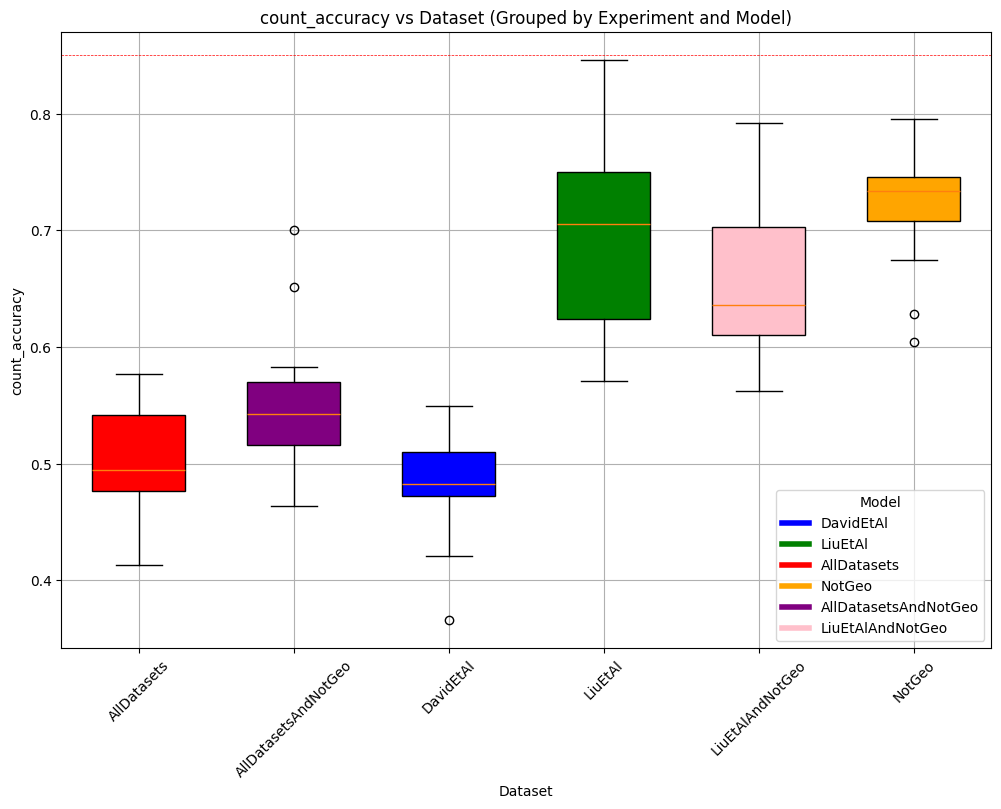

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'count_accuracy_avg' column to 0
filtered_df['count_accuracy_avg'] = filtered_df['count_accuracy_avg'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy')
plt.title('count_accuracy vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

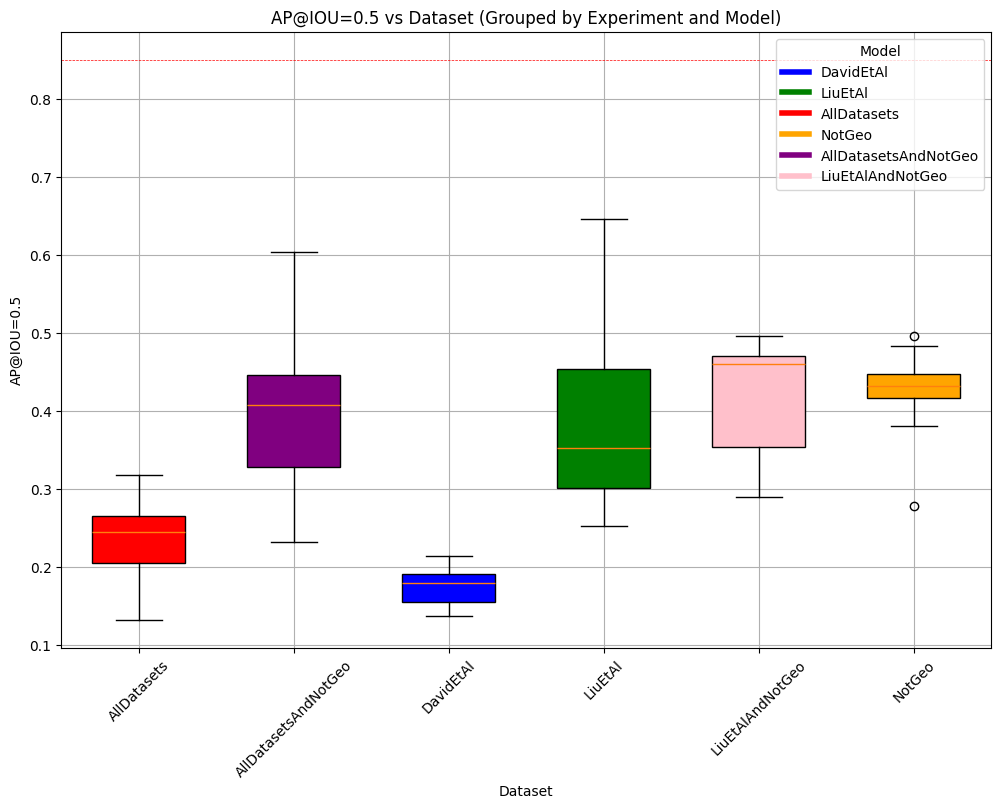

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['ap_iou_50'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

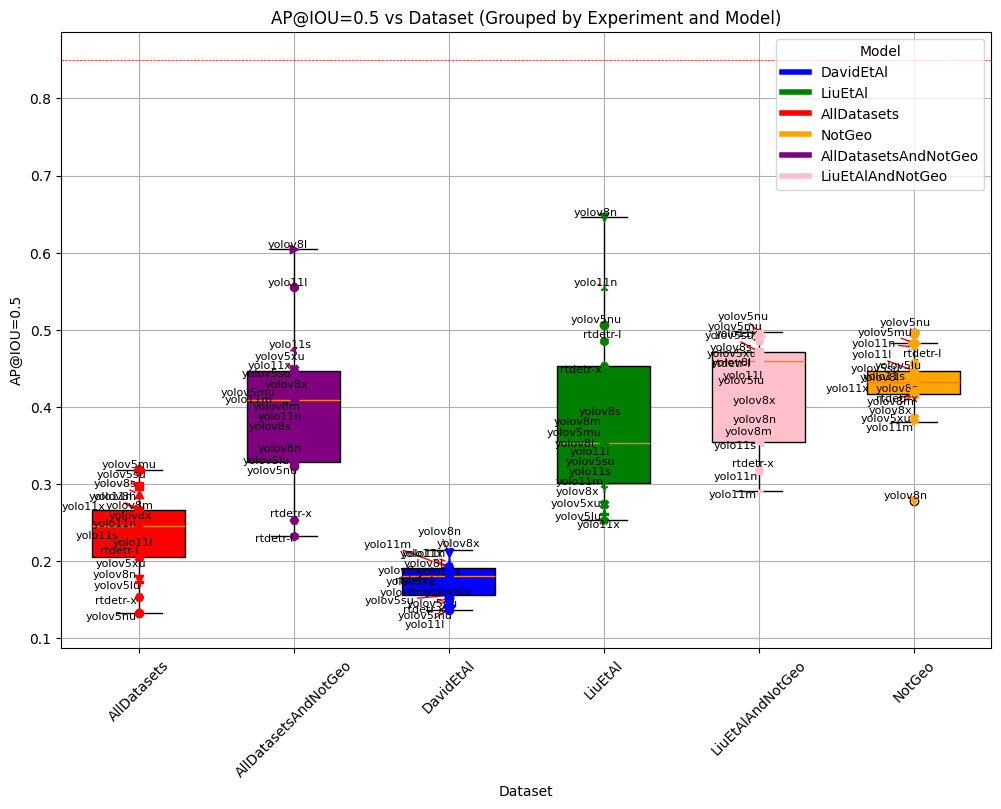

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['ap_iou_50'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['ap_iou_50'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['ap_iou_50'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

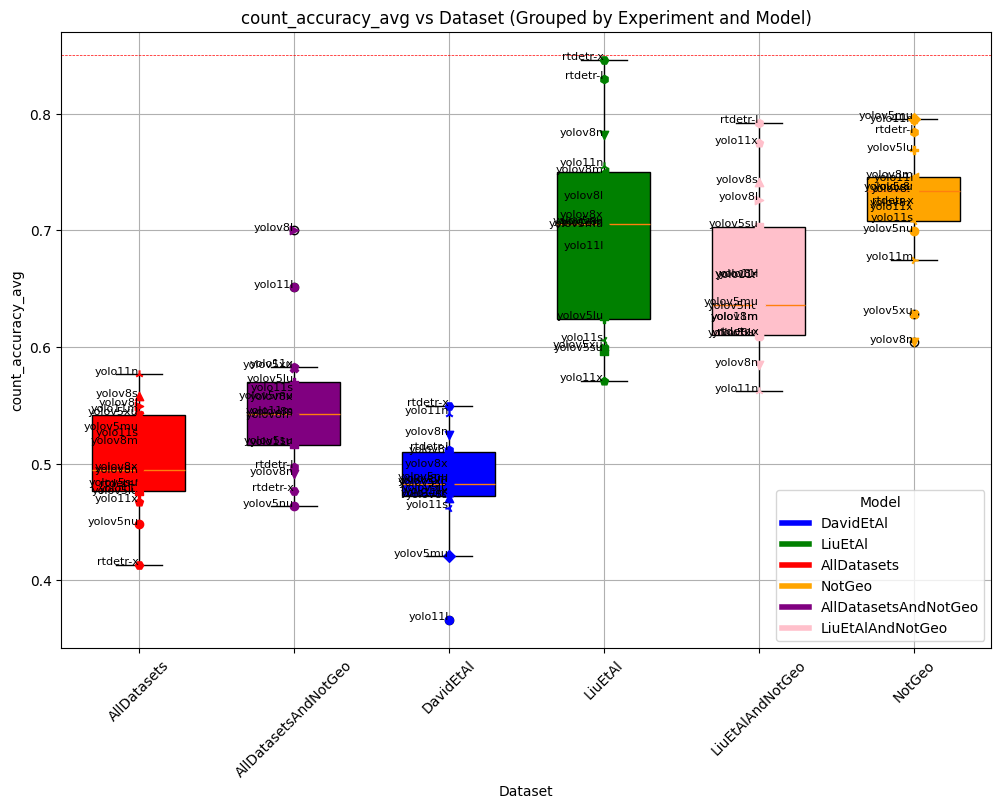

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

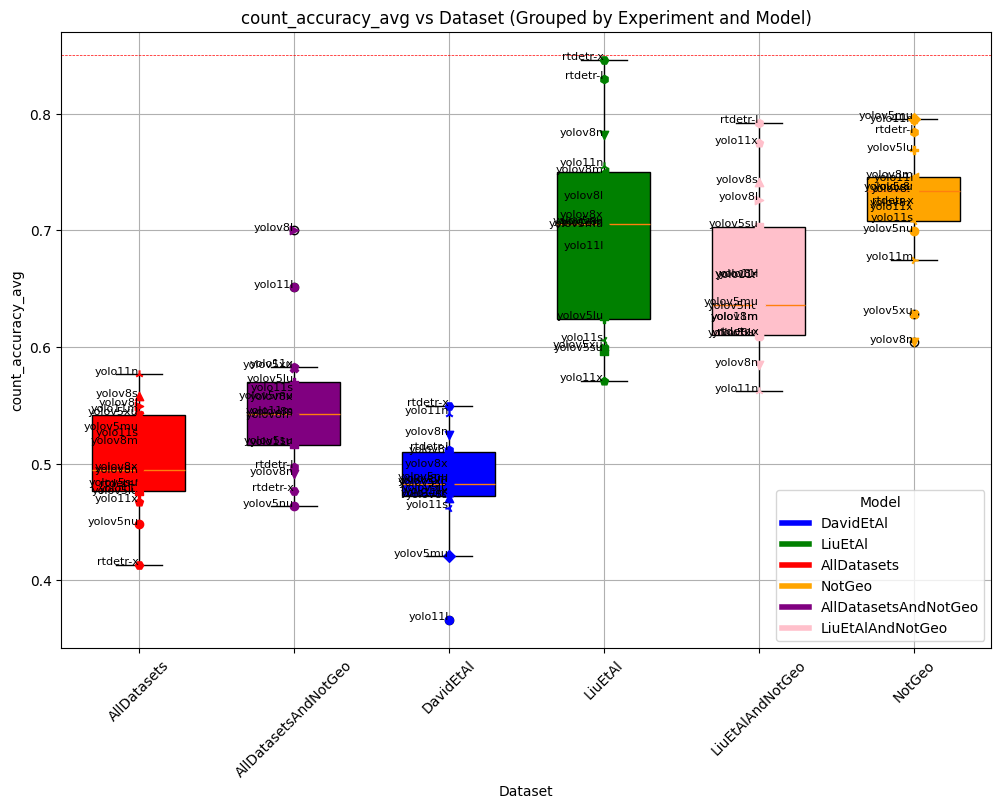

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

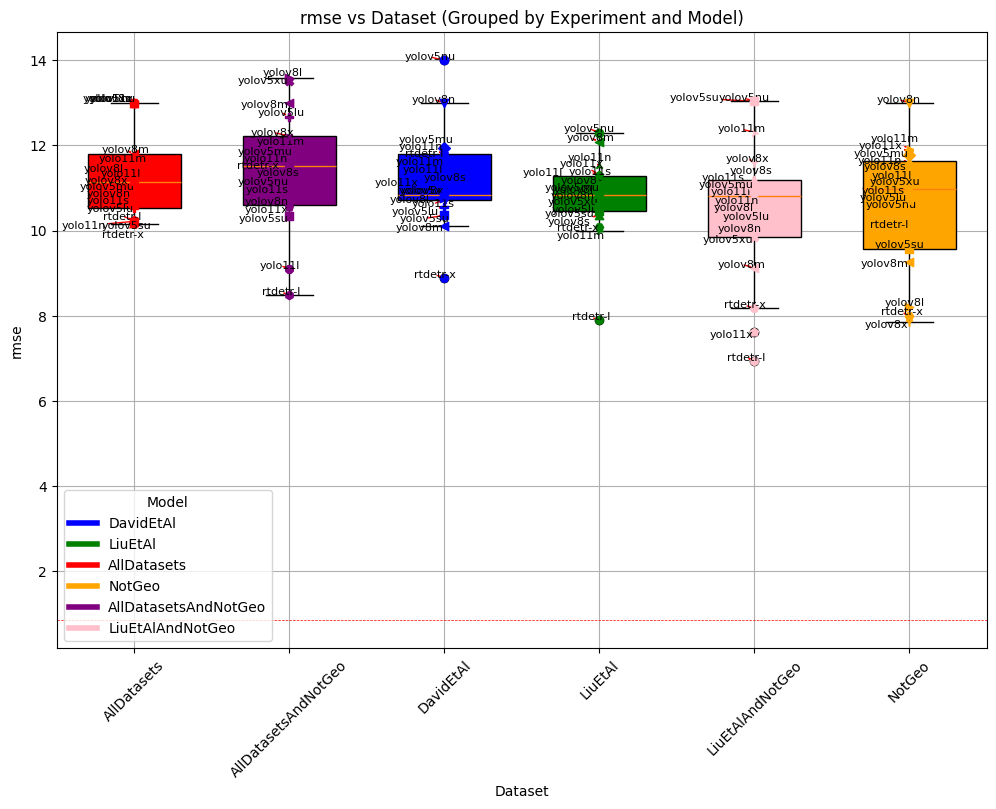

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'rmse' column to 0
filtered_df['rmse'] = filtered_df['rmse'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['rmse'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['rmse'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['rmse'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['rmse'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['rmse'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('rmse')
plt.title('rmse vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()